<a href="https://colab.research.google.com/github/DavidAromose/smartphone-tick-identification/blob/main/tick_sdm_phase4_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
R.version.string

[1] "R version 4.6.0 (2026-04-24)"

In [ ]:
system("pip install google-colab 2>/dev/null")
# Drive mount in R Colab:
dir.create("/content/drive", showWarnings = FALSE)
system("google-drive-ocamlfuse /content/drive", ignore.stderr = TRUE)

Warning message in system("google-drive-ocamlfuse /content/drive", ignore.stderr = TRUE):
“error in running command”


In [ ]:
install.packages(c("rgbif", "dplyr"), quiet = TRUE)

library(rgbif)
library(dplyr)

species_list <- c(
  "Dermacentor reticulatus",
  "Hyalomma marginatum",
  "Ixodes hexagonus",
  "Ixodes ricinus",
  "Rhipicephalus sanguineus"
)

keys <- sapply(species_list, function(sp) {
  name_backbone(name = sp)$usageKey
})

print(data.frame(species = species_list, gbif_key = keys))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




                                          species gbif_key
Dermacentor reticulatus   Dermacentor reticulatus  2183432
Hyalomma marginatum           Hyalomma marginatum  4548126
Ixodes hexagonus                 Ixodes hexagonus  2182405
Ixodes ricinus                     Ixodes ricinus  2182588
Rhipicephalus sanguineus Rhipicephalus sanguineus  2183597


In [ ]:
library(rgbif)
library(dplyr)

# European bounding box (well WKT polygon: lon/lat)
europe_wkt <- "POLYGON((-25 34, 45 34, 45 72, -25 72, -25 34))"

# Download occurrences per species with methodology filters
all_occ <- list()

for (i in seq_along(species_list)) {
  sp  <- species_list[i]
  key <- keys[i]
  cat("Fetching:", sp, "...\n")

  res <- occ_search(
    taxonKey       = key,
    hasCoordinate  = TRUE,
    hasGeospatialIssue = FALSE,
    year           = "2015,2025",
    geometry       = europe_wkt,
    limit          = 5000,
    fields         = c("species", "decimalLatitude", "decimalLongitude",
                       "year", "coordinateUncertaintyInMeters",
                       "countryCode", "basisOfRecord")
  )

  df <- res$data
  if (!is.null(df) && nrow(df) > 0) {
    df$target_species <- sp
    all_occ[[sp]] <- df
    cat("   ->", nrow(df), "records\n")
  } else {
    cat("   -> 0 records\n")
  }
}

# Combine into one table
occ_raw <- bind_rows(all_occ)
cat("\nTOTAL raw records:", nrow(occ_raw), "\n")
print(table(occ_raw$target_species))

Fetching: Dermacentor reticulatus ...
   -> 4444 records
Fetching: Hyalomma marginatum ...
   -> 841 records
Fetching: Ixodes hexagonus ...
   -> 1246 records
Fetching: Ixodes ricinus ...
   -> 5000 records
Fetching: Rhipicephalus sanguineus ...
   -> 542 records

TOTAL raw records: 12073 

 Dermacentor reticulatus      Hyalomma marginatum         Ixodes hexagonus 
                    4444                      841                     1246 
          Ixodes ricinus Rhipicephalus sanguineus 
                    5000                      542 


In [ ]:
library(dplyr)

# Start from raw
occ_clean <- occ_raw %>%
  # Must have valid coordinates
  filter(!is.na(decimalLatitude), !is.na(decimalLongitude)) %>%
  # Coordinate uncertainty <= 1 km (keep NA uncertainty — many citizen records omit it)
  filter(is.na(coordinateUncertaintyInMeters) |
         coordinateUncertaintyInMeters <= 1000) %>%
  # Remove exact coordinate duplicates within each species
  distinct(target_species, decimalLatitude, decimalLongitude, .keep_all = TRUE)

cat("Records after cleaning:", nrow(occ_clean), "\n\n")
print(table(occ_clean$target_species))

Records after cleaning: 6315 


 Dermacentor reticulatus      Hyalomma marginatum         Ixodes hexagonus 
                    2437                      590                     1015 
          Ixodes ricinus Rhipicephalus sanguineus 
                    1880                      393 


In [ ]:
install.packages(c("geodata", "terra"), quiet = TRUE)

library(geodata)
library(terra)

# Download WorldClim v2.1 bioclim variables (~1km = 0.5 res; using 2.5 arc-min for continental scale)
# res options: 10, 5, 2.5, 0.5 (arc-minutes). 2.5 is the sensible continental choice.
bioclim <- worldclim_global(var = "bio", res = 2.5, path = "/content/wc_data")

cat("Downloaded", nlyr(bioclim), "bioclimatic layers\n")
print(bioclim)

Loading required package: terra

terra 1.9.34

Cached as: /content/wc_data/climate/wc2.1_2.5m//wc2.1_2.5m_bio.zip



Downloaded 19 bioclimatic layers
class       : SpatRaster
size        : 4320, 8640, 19  (nrow, ncol, nlyr)
resolution  : 0.04166667, 0.04166667  (x, y)
extent      : -180, 180, -90, 90  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326)
sources     : wc2.1_2.5m_bio_1.tif
              wc2.1_2.5m_bio_2.tif
              wc2.1_2.5m_bio_3.tif
              ... and 16 more sources
names       : wc2.1~bio_1, wc2.1~bio_2, wc2.1~bio_3, wc2.1~bio_4, wc2.1~bio_5, wc2.1~bio_6, ...
min values  :  -54.759167,           1,    9.063088,           0,      -30.76,  -72.503998, ...
max values  :   31.166666,      21.973,         100, 2377.624023,   48.459999,   26.450001, ...


In [ ]:
library(terra)
library(dplyr)

# European extent (xmin, xmax, ymin, ymax) — matches the occurrence bounding box
europe_ext <- ext(-25, 45, 34, 72)
bioclim_eu <- crop(bioclim, europe_ext)

# Tidy layer names to bio1..bio19
names(bioclim_eu) <- paste0("bio", 1:19)
cat("Cropped to Europe:", nlyr(bioclim_eu), "layers\n")

# Build a SpatVector of occurrence points
pts <- vect(occ_clean,
            geom = c("decimalLongitude", "decimalLatitude"),
            crs  = "EPSG:4326")

# Extract climate values at each occurrence point
occ_env <- terra::extract(bioclim_eu, pts)

# Attach species labels + coords, drop the ID column and any points with no climate data
occ_env$target_species    <- occ_clean$target_species
occ_env$decimalLongitude  <- occ_clean$decimalLongitude
occ_env$decimalLatitude   <- occ_clean$decimalLatitude
occ_env <- occ_env %>% select(-ID) %>% filter(!is.na(bio1))

cat("Occurrences with valid climate data:", nrow(occ_env), "\n\n")
print(table(occ_env$target_species))

Cropped to Europe: 19 layers
Occurrences with valid climate data: 6303 


 Dermacentor reticulatus      Hyalomma marginatum         Ixodes hexagonus 
                    2431                      587                     1013 
          Ixodes ricinus Rhipicephalus sanguineus 
                    1879                      393 


In [ ]:
write.csv(occ_env, "/content/occ_env_5species.csv", row.names = FALSE)
cat("Saved modelling-ready data:", nrow(occ_env), "records\n")

Saved modelling-ready data: 6303 records


In [ ]:
install.packages("ENMeval", quiet = TRUE)

library(terra)
library(ENMeval)
library(dplyr)

# 10,000 random background points from the European climate extent
set.seed(42)  # reproducibility
bg <- spatSample(bioclim_eu[[1]], size = 10000,
                 method = "random", na.rm = TRUE,
                 as.points = TRUE, values = FALSE)
bg_coords <- as.data.frame(geom(bg))[, c("x", "y")]
names(bg_coords) <- c("longitude", "latitude")

cat("Background points generated:", nrow(bg_coords), "\n")
head(bg_coords)

also installing the dependencies ‘sp’, ‘proxy’, ‘crosstalk’, ‘leaflet.providers’, ‘png’, ‘raster’, ‘svglite’, ‘e1071’, ‘assertthat’, ‘maps’, ‘leaflet’, ‘kableExtra’, ‘cowplot’, ‘classInt’, ‘units’, ‘rebird’, ‘rvertnet’, ‘ridigbio’, ‘wk’, ‘s2’, ‘RPostgreSQL’, ‘ape’, ‘sf’, ‘doParallel’, ‘iterators’, ‘shape’, ‘RcppEigen’, ‘spocc’, ‘BIEN’, ‘maxnet’, ‘predicts’, ‘foreach’, ‘glmnet’, ‘rangeModelMetadata’


This is ENMeval version 2.0.5.2. 
For worked examples, please consult the vignette: <https://jamiemkass.github.io/ENMeval/articles/ENMeval-2.0-vignette.html>.



Background points generated: 10000 


,longitude,latitude
,<dbl>,<dbl>
1,-18.56250,64.31250
2,39.72917,65.47917
3,19.93750,43.47917
4,30.77083,60.43750
5,21.93750,52.93750
6,25.39583,49.72917


In [ ]:
library(ENMeval)
library(dplyr)

# Presence coordinates for I. ricinus
sp_name <- "Ixodes ricinus"
occs_sp <- occ_env %>%
  filter(target_species == sp_name) %>%
  select(longitude = decimalLongitude, latitude = decimalLatitude)

cat("Running ENMeval for", sp_name, "-", nrow(occs_sp), "presences\n")
cat("This takes a few minutes...\n")

# Run ENMeval: maxnet engine, spatial block CV, tuning over FC x RM grid
eval_ricinus <- ENMevaluate(
  occs        = occs_sp,
  envs        = bioclim_eu,
  bg          = bg_coords,
  algorithm   = "maxnet",
  partitions  = "block",              # spatial block cross-validation
  tune.args   = list(
    fc = c("L", "LQ", "LQH"),         # feature classes
    rm = c(0.5, 1, 2)                 # regularisation multipliers
  ),
  parallel    = FALSE
)

cat("\nDONE. Results summary:\n")
print(eval_ricinus@results[, c("fc", "rm", "auc.val.avg", "auc.diff.avg",
                               "or.10p.avg", "AICc", "delta.AICc")])

Running ENMeval for Ixodes ricinus - 1879 presences
This takes a few minutes...


Package ecospat is not installed, so Continuous Boyce Index (CBI) cannot be calculated.

*** Running initial checks... ***


* Removed 352 occurrence localities that shared the same grid cell.

* Clamping predictor variable rasters...

* Model evaluations with spatial block (4-fold) cross validation and lat_lon orientation...


*** Running ENMeval v2.0.5 with maxnet from maxnet package v0.1.4 ***




  |======================================================================| 100%


Making model prediction rasters...

ENMevaluate completed in 27 minutes 14 seconds.




DONE. Results summary:
   fc  rm auc.val.avg auc.diff.avg or.10p.avg     AICc delta.AICc
1   L 0.5   0.8584741   0.06294448  0.1520077 38055.94  1375.2078
2  LQ 0.5   0.8846075   0.05830126  0.1748928 37103.39   422.6538
3 LQH 0.5   0.8899255   0.04381851  0.2174544 36680.74     0.0000
4   L 1.0   0.8455550   0.06955945  0.1559017 38226.50  1545.7608
5  LQ 1.0   0.8758348   0.05953815  0.1611425 37401.35   720.6141
6 LQH 1.0   0.8902239   0.04229544  0.2056640 36827.90   147.1697
7   L 2.0   0.8412691   0.06843916  0.1565253 38379.44  1698.7074
8  LQ 2.0   0.8729357   0.06003632  0.1578943 37681.09  1000.3559
9 LQH 2.0   0.8938637   0.04082089  0.1794671 36975.78   295.0492


In [ ]:
saveRDS(eval_ricinus, "/content/enmeval_Ixodes_ricinus.rds")
write.csv(eval_ricinus@results, "/content/results_Ixodes_ricinus.csv", row.names = FALSE)
cat("Saved I. ricinus ENMeval results\n")

Saved I. ricinus ENMeval results


In [ ]:
library(ENMeval)
library(dplyr)

# ==== CHANGE THESE TWO LINES PER SPECIES ====
sp_name  <- "Dermacentor reticulatus"
out_tag  <- "Dermacentor_reticulatus"
# ============================================

occs_sp <- occ_env %>%
  filter(target_species == sp_name) %>%
  select(longitude = decimalLongitude, latitude = decimalLatitude)

cat("Running ENMeval for", sp_name, "-", nrow(occs_sp), "presences\n")
cat("Parallel mode on; this should be faster than the first run...\n")

eval_sp <- ENMevaluate(
  occs        = occs_sp,
  envs        = bioclim_eu,
  bg          = bg_coords,
  algorithm   = "maxnet",
  partitions  = "block",
  tune.args   = list(
    fc = c("L", "LQ", "LQH"),
    rm = c(0.5, 1, 2)
  ),
  parallel    = TRUE,
  numCores    = 2
)

# Save immediately (protects against later disconnects)
saveRDS(eval_sp, paste0("/content/enmeval_", out_tag, ".rds"))
write.csv(eval_sp@results, paste0("/content/results_", out_tag, ".csv"),
          row.names = FALSE)

cat("\nDONE & SAVED:", sp_name, "\n")
print(eval_sp@results[, c("fc", "rm", "auc.val.avg", "auc.diff.avg",
                          "or.10p.avg", "AICc", "delta.AICc")])

Running ENMeval for Dermacentor reticulatus - 2431 presences
Parallel mode on; this should be faster than the first run...


Package ecospat is not installed, so Continuous Boyce Index (CBI) cannot be calculated.

*** Running initial checks... ***


* Removed 679 occurrence localities that shared the same grid cell.

* Clamping predictor variable rasters...

* Model evaluations with spatial block (4-fold) cross validation and lat_lon orientation...


*** Running ENMeval v2.0.5 with maxnet from maxnet package v0.1.4 ***



Of 2 total cores using 2...

Running in parallel ...

Making model prediction rasters...

ENMevaluate completed in 28 minutes 57.9 seconds.




DONE & SAVED: Dermacentor reticulatus 
   fc  rm auc.val.avg auc.diff.avg or.10p.avg     AICc delta.AICc
1   L 0.5   0.6744337    0.2057989  0.3704338 45538.78  1596.2906
2  LQ 0.5   0.7289751    0.1784374  0.3384703 44792.98   850.4987
3 LQH 0.5   0.7374655    0.1613197  0.3750000 43942.49     0.0000
4   L 1.0   0.6757883    0.2055577  0.3607306 45668.96  1726.4762
5  LQ 1.0   0.6893262    0.2136364  0.4006849 45096.56  1154.0758
6 LQH 1.0   0.7599527    0.1385172  0.2882420 44103.41   160.9278
7   L 2.0   0.6652350    0.2118289  0.3647260 45800.59  1858.1008
8  LQ 2.0   0.6475978    0.2525337  0.4229452 45489.71  1547.2247
9 LQH 2.0   0.7463620    0.1476256  0.3356164 44295.53   353.0437


In [ ]:
library(ENMeval)
library(dplyr)

# ==== CHANGE THESE TWO LINES PER SPECIES ====
sp_name  <- "Hyalomma marginatum"
out_tag  <- "Hyalomma_marginatum"
# ============================================

occs_sp <- occ_env %>%
  filter(target_species == sp_name) %>%
  select(longitude = decimalLongitude, latitude = decimalLatitude)

cat("Running ENMeval for", sp_name, "-", nrow(occs_sp), "presences\n")

eval_sp <- ENMevaluate(
  occs        = occs_sp,
  envs        = bioclim_eu,
  bg          = bg_coords,
  algorithm   = "maxnet",
  partitions  = "block",
  tune.args   = list(
    fc = c("L", "LQ", "LQH"),
    rm = c(0.5, 1, 2)
  ),
  raster.preds = FALSE,   # <-- skip per-model rasters during tuning (big speedup)
  parallel     = FALSE
)

saveRDS(eval_sp, paste0("/content/enmeval_", out_tag, ".rds"))
write.csv(eval_sp@results, paste0("/content/results_", out_tag, ".csv"),
          row.names = FALSE)

cat("\nDONE & SAVED:", sp_name, "\n")
print(eval_sp@results[, c("fc", "rm", "auc.val.avg", "auc.diff.avg",
                          "or.10p.avg", "AICc", "delta.AICc")])

Running ENMeval for Hyalomma marginatum - 587 presences


Package ecospat is not installed, so Continuous Boyce Index (CBI) cannot be calculated.

*** Running initial checks... ***


* Removed 57 occurrence localities that shared the same grid cell.

* Clamping predictor variable rasters...

* Model evaluations with spatial block (4-fold) cross validation and lat_lon orientation...


*** Running ENMeval v2.0.5 with maxnet from maxnet package v0.1.4 ***




  |======================================================================| 100%


ENMevaluate completed in 11 minutes 13.5 seconds.




DONE & SAVED: Hyalomma marginatum 
   fc  rm auc.val.avg auc.diff.avg or.10p.avg     AICc delta.AICc
1   L 0.5   0.8117144   0.10118387  0.2006294 13299.89  257.73465
2  LQ 0.5   0.8283996   0.07198243  0.1304397 13112.80   70.64320
3 LQH 0.5   0.8528243   0.05702262  0.1569549 13100.00   57.84464
4   L 1.0   0.8092611   0.10799733  0.1912167 13316.83  274.66828
5  LQ 1.0   0.8213073   0.08311045  0.1399522 13146.60  104.44400
6 LQH 1.0   0.8527596   0.05379993  0.1210128 13042.16    0.00000
7   L 2.0   0.8074971   0.11355867  0.1874430 13351.59  309.43424
8  LQ 2.0   0.8190834   0.08902301  0.1323764 13227.77  185.61746
9 LQH 2.0   0.8405107   0.05467768  0.1209558 13086.71   44.55598


In [ ]:
library(ENMeval)
library(dplyr)

# ==== CHANGE THESE TWO LINES PER SPECIES ====
sp_name  <- "Ixodes hexagonus"
out_tag  <- "Ixodes_hexagonus"
# ============================================

occs_sp <- occ_env %>%
  filter(target_species == sp_name) %>%
  select(longitude = decimalLongitude, latitude = decimalLatitude)

cat("Running ENMeval for", sp_name, "-", nrow(occs_sp), "presences\n")

eval_sp <- ENMevaluate(
  occs        = occs_sp,
  envs        = bioclim_eu,
  bg          = bg_coords,
  algorithm   = "maxnet",
  partitions  = "block",
  tune.args   = list(
    fc = c("L", "LQ", "LQH"),
    rm = c(0.5, 1, 2)
  ),
  raster.preds = FALSE,
  parallel     = FALSE
)

saveRDS(eval_sp, paste0("/content/enmeval_", out_tag, ".rds"))
write.csv(eval_sp@results, paste0("/content/results_", out_tag, ".csv"),
          row.names = FALSE)

cat("\nDONE & SAVED:", sp_name, "\n")
print(eval_sp@results[, c("fc", "rm", "auc.val.avg", "auc.diff.avg",
                          "or.10p.avg", "AICc", "delta.AICc")])

Running ENMeval for Ixodes hexagonus - 1013 presences


Package ecospat is not installed, so Continuous Boyce Index (CBI) cannot be calculated.

*** Running initial checks... ***


* Removed 136 occurrence localities that shared the same grid cell.

* Clamping predictor variable rasters...

* Model evaluations with spatial block (4-fold) cross validation and lat_lon orientation...


*** Running ENMeval v2.0.5 with maxnet from maxnet package v0.1.4 ***




  |======================================================================| 100%


ENMevaluate completed in 17 minutes 8.5 seconds.




DONE & SAVED: Ixodes hexagonus 
   fc  rm auc.val.avg auc.diff.avg or.10p.avg     AICc delta.AICc
1   L 0.5   0.9375853   0.03373764  0.1665888 20253.62   801.5547
2  LQ 0.5   0.9444194   0.03892834  0.2270496 19903.32   451.2515
3 LQH 0.5   0.9532419   0.02979472  0.2646534 19452.07     0.0000
4   L 1.0   0.9323611   0.03790891  0.1745486 20417.02   964.9495
5  LQ 1.0   0.9354599   0.04616473  0.2064965 20195.40   743.3267
6 LQH 1.0   0.9524731   0.03071319  0.2612599 19562.16   110.0940
7   L 2.0   0.9302694   0.04213741  0.1779992 20514.81  1062.7382
8  LQ 2.0   0.9354933   0.04524152  0.1996835 20350.16   898.0929
9 LQH 2.0   0.9515335   0.03218224  0.2453196 19682.06   229.9911


In [ ]:
library(ENMeval)
library(dplyr)

# ==== CHANGE THESE TWO LINES PER SPECIES ====
sp_name  <- "Rhipicephalus sanguineus"
out_tag  <- "Rhipicephalus_sanguineus"
# ============================================

occs_sp <- occ_env %>%
  filter(target_species == sp_name) %>%
  select(longitude = decimalLongitude, latitude = decimalLatitude)

cat("Running ENMeval for", sp_name, "-", nrow(occs_sp), "presences\n")

eval_sp <- ENMevaluate(
  occs        = occs_sp,
  envs        = bioclim_eu,
  bg          = bg_coords,
  algorithm   = "maxnet",
  partitions  = "block",
  tune.args   = list(
    fc = c("L", "LQ", "LQH"),
    rm = c(0.5, 1, 2)
  ),
  raster.preds = FALSE,
  parallel     = FALSE
)

saveRDS(eval_sp, paste0("/content/enmeval_", out_tag, ".rds"))
write.csv(eval_sp@results, paste0("/content/results_", out_tag, ".csv"),
          row.names = FALSE)

cat("\nDONE & SAVED:", sp_name, "\n")
print(eval_sp@results[, c("fc", "rm", "auc.val.avg", "auc.diff.avg",
                          "or.10p.avg", "AICc", "delta.AICc")])

Running ENMeval for Rhipicephalus sanguineus - 393 presences


Package ecospat is not installed, so Continuous Boyce Index (CBI) cannot be calculated.

*** Running initial checks... ***


* Removed 48 occurrence localities that shared the same grid cell.

* Clamping predictor variable rasters...

* Model evaluations with spatial block (4-fold) cross validation and lat_lon orientation...


*** Running ENMeval v2.0.5 with maxnet from maxnet package v0.1.4 ***




  |======================================================================| 100%


ENMevaluate completed in 8 minutes 38.9 seconds.




DONE & SAVED: Rhipicephalus sanguineus 
   fc  rm auc.val.avg auc.diff.avg or.10p.avg     AICc delta.AICc
1   L 0.5   0.7840741   0.12665962  0.2729217 8591.118 200.070925
2  LQ 0.5   0.8384368   0.07605843  0.2004143 8392.561   1.514412
3 LQH 0.5   0.8350927   0.08986192  0.3770716 8391.047   0.000000
4   L 1.0   0.7967955   0.12101033  0.2322240 8609.833 218.785882
5  LQ 1.0   0.8190337   0.08836695  0.2353315 8453.298  62.251645
6 LQH 1.0   0.8213652   0.10260301  0.3567562 8417.205  26.158010
7   L 2.0   0.7977005   0.11632787  0.1973737 8630.232 239.185450
8  LQ 2.0   0.8193241   0.08304158  0.2409449 8535.357 144.310053
9 LQH 2.0   0.8219759   0.09801912  0.3016239 8421.081  30.033892


In [ ]:
library(ENMeval)
library(terra)

# Chosen model per species: named vector of tune.args tags
chosen <- c(
  "Ixodes_hexagonus"         = "fc.LQH_rm.0.5",
  "Ixodes_ricinus"           = "fc.LQH_rm.0.5",
  "Hyalomma_marginatum"      = "fc.LQH_rm.1",
  "Rhipicephalus_sanguineus" = "fc.LQ_rm.0.5",
  "Dermacentor_reticulatus"  = "fc.LQH_rm.1"
)

dir.create("/content/suitability", showWarnings = FALSE)
suit_stack <- list()

for (tag in names(chosen)) {
  cat("Predicting:", tag, "->", chosen[tag], "\n")
  e   <- readRDS(paste0("/content/enmeval_", tag, ".rds"))
  mod <- e@models[[ chosen[tag] ]]                    # the chosen tuned model
  # cloglog suitability prediction across Europe
  pred <- predict(bioclim_eu, mod, type = "cloglog", na.rm = TRUE)
  names(pred) <- tag
  writeRaster(pred, paste0("/content/suitability/", tag, "_suitability.tif"),
              overwrite = TRUE)
  suit_stack[[tag]] <- pred
}

cat("\nAll suitability rasters generated.\n")

Predicting: Ixodes_hexagonus -> fc.LQH_rm.0.5 
Predicting: Ixodes_ricinus -> fc.LQH_rm.0.5 
Predicting: Hyalomma_marginatum -> fc.LQH_rm.1 
Predicting: Rhipicephalus_sanguineus -> fc.LQ_rm.0.5 
Predicting: Dermacentor_reticulatus -> fc.LQH_rm.1 

All suitability rasters generated.


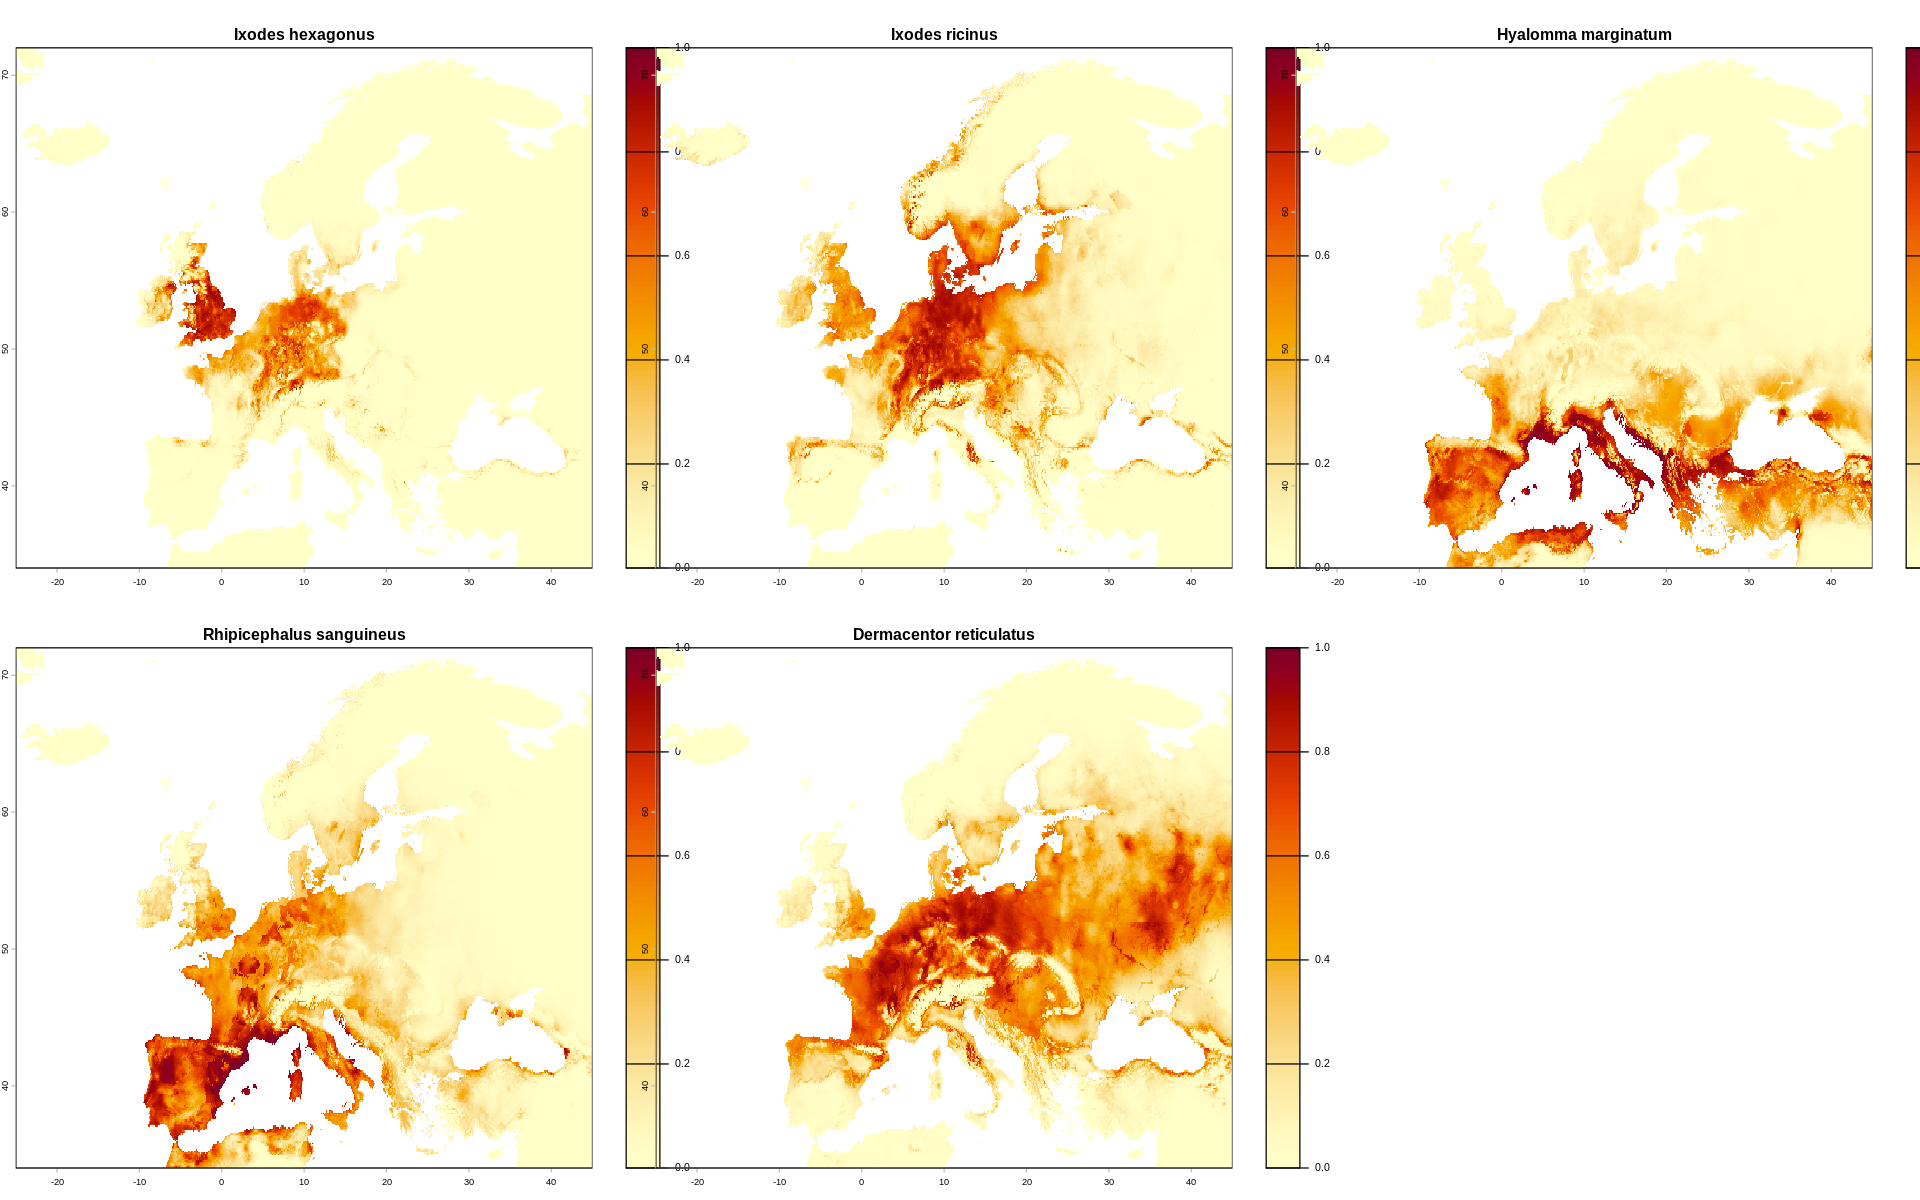

In [ ]:
library(terra)

# Load the five suitability rasters into a stack
tags <- c("Ixodes_hexagonus", "Ixodes_ricinus", "Hyalomma_marginatum",
          "Rhipicephalus_sanguineus", "Dermacentor_reticulatus")

suit <- rast(paste0("/content/suitability/", tags, "_suitability.tif"))

# Plot all five in a panel
options(repr.plot.width = 16, repr.plot.height = 10)
plot(suit,
     col = hcl.colors(100, "YlOrRd", rev = TRUE),
     range = c(0, 1),
     main = gsub("_", " ", tags),
     nc = 3, nr = 2)

In [ ]:
setwd("/content")
zip(zipfile = "phase4_sdm_outputs.zip",
    files = c("suitability",
              list.files("/content", pattern = "^enmeval_.*\\.rds$"),
              list.files("/content", pattern = "^results_.*\\.csv$"),
              list.files("/content", pattern = "^occ_.*\\.csv$")))
cat("Created phase4_sdm_outputs.zip\n")
list.files("/content", pattern = "\\.zip$")

Created phase4_sdm_outputs.zip


[1] "phase4_sdm_outputs.zip"